# 01 — Hold-out validation for oncology PK/PD models

This notebook validates the model family discovered in notebook 00.

Notebook 00 showed strong in-sample improvement:

- Simeoni median RMSE ≈ 0.290
- best simple model median RMSE ≈ 0.241
- final selected conservative median RMSE ≈ 0.151

But that was **in-sample**.

Here we test whether the model generalizes:

1. Select the same 20-patient cohort from notebook 00.
2. For each patient, split scans into:
   - training scans: early 70–75%
   - held-out scans: late 25–30%
3. Fit models only on training scans.
4. Predict the held-out scans.
5. Compare train RMSE, test RMSE, BIC-like complexity penalties, and model-selection stability.

Models tested:

- Simeoni
- Simeoni + joint observation shift
- nested resistant-Simeoni
- nested resistant-Simeoni + post-hoc observation shift

Main question:

> Does the nested resistant model still help when predicting future scans?

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "data").exists() and ((parent / "src").exists() or (parent / "outputs").exists()):
        PROJECT_ROOT = parent
        break

DATA_ROOT = PROJECT_ROOT / "data"

PREV_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_00_audit_and_fit"
OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_01_holdout_validation"
PLOT_DIR = OUT_DIR / "plots"

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:   ", DATA_ROOT)
print("PREV_OUT_DIR:", PREV_OUT_DIR)
print("OUT_DIR:     ", OUT_DIR)

assert PREV_OUT_DIR.exists(), f"Missing previous notebook output directory: {PREV_OUT_DIR}"

PROJECT_ROOT: d:\Projects\ml_redo\oncology-sbi-pkpd
DATA_ROOT:    d:\Projects\ml_redo\oncology-sbi-pkpd\data
PREV_OUT_DIR: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_00_audit_and_fit
OUT_DIR:      d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation


In [2]:
# ---------------------------------------------------------------------
# Load canonical data and previous model-discovery cohort
# ---------------------------------------------------------------------

obs_path = PREV_OUT_DIR / "ALL_observations.csv"
dose_path = PREV_OUT_DIR / "ALL_doses.csv"
final_selection_path = PREV_OUT_DIR / "batch_20_final_conservative_model_selection.csv"

if not obs_path.exists():
    raise FileNotFoundError(f"Missing {obs_path}. Run notebook 00 first.")

if not dose_path.exists():
    raise FileNotFoundError(f"Missing {dose_path}. Run notebook 00 first.")

if not final_selection_path.exists():
    raise FileNotFoundError(f"Missing {final_selection_path}. Run notebook 00 final selection first.")

all_observations = pd.read_csv(obs_path, dtype={"patient_id": str})
all_doses = pd.read_csv(dose_path, dtype={"patient_id": str})
previous_selection = pd.read_csv(final_selection_path, dtype={"patient_id": str})

print("Observations:", all_observations.shape)
print("Doses:       ", all_doses.shape)
print("Previous selection:", previous_selection.shape)

display(previous_selection.head())

Observations: (28562, 9)
Doses:        (352854, 8)
Previous selection: (20, 37)


,study_id,patient_id,status,n_scans,elapsed_s,simeoni_rmse,joint_shift_rmse,best_existing_model,best_existing_rmse,nested_rmse,...,nr_k_kill_r_frac,nr_k_sr,nr_lam0_r,nr_k_kill_r,nr_near_bound_count,nr_nfev,nr_optimizer_success,final_selected_model,final_selected_rmse,selection_reason
0,DATASET_263,203614005,nested_all_ok,16,65.172373,0.612228,0.612228,Simeoni,0.612228,0.191271,...,0.006221,0.000037,0.001420,0.000069,1,9,True,NestedResistantSimeoni_plus_posthoc_shift,0.152506,accept_nested_plus_shift
1,DATASET_263,203303005,nested_all_ok,15,18.240967,0.530365,0.496397,Simeoni,0.530365,0.499765,...,0.040356,0.000096,0.003012,0.000735,1,7,True,Simeoni,0.530365,keep_existing
2,DATASET_263,201101018,nested_all_ok,14,96.722052,0.101665,0.090342,Simeoni,0.101665,0.108021,...,0.001021,0.000020,0.004671,0.000003,1,10,True,Simeoni,0.101665,keep_existing
3,DATASET_263,203404002,nested_all_ok,14,22.835515,0.350229,0.318300,Simeoni,0.350229,0.188313,...,0.548753,0.016323,0.000983,0.001028,3,9,True,NestedResistantSimeoni_plus_posthoc_shift,0.156543,accept_nested_plus_shift
4,DATASET_263,203613003,nested_all_ok,14,80.673237,0.083790,0.057841,Simeoni_plus_joint_observation_shift,0.057841,0.086580,...,0.143868,0.000078,0.004438,0.000471,0,10,True,Simeoni_plus_joint_observation_shift,0.057841,keep_existing


In [3]:
# ---------------------------------------------------------------------
# Validation cohort
# ---------------------------------------------------------------------

# Use the same 20 patients from notebook 00.
VALIDATION_N_PATIENTS = 20

validation_patients = (
    previous_selection[["study_id", "patient_id"]]
    .drop_duplicates()
    .head(VALIDATION_N_PATIENTS)
    .copy()
)

display(validation_patients)

print("Validation patients:", len(validation_patients))

,study_id,patient_id
0,DATASET_263,203614005
1,DATASET_263,203303005
2,DATASET_263,201101018
3,DATASET_263,203404002
4,DATASET_263,203613003
5,DATASET_263,203707002
6,DATASET_263,201103021
7,DATASET_263,203402003
8,DATASET_263,203703003
9,DATASET_263,201715002


Validation patients: 20


In [4]:
# ---------------------------------------------------------------------
# Clinical trajectory and dose helpers
# ---------------------------------------------------------------------

def _norm_patient_id(x: object) -> str:
    s = str(x).strip()
    return s.lstrip("0") if s.isdigit() else s


def get_patient_observations(
    observations: pd.DataFrame,
    study_id: str,
    patient_id: str,
) -> pd.DataFrame:
    df = observations.copy()
    df["_study_match"] = df["study_id"].astype(str).str.strip()
    df["_patient_match"] = df["patient_id"].map(_norm_patient_id)

    mask = (
        (df["_study_match"] == str(study_id).strip())
        & (df["_patient_match"] == _norm_patient_id(patient_id))
    )

    return (
        df[mask]
        .drop(columns=["_study_match", "_patient_match"])
        .sort_values("time_days")
        .copy()
    )


def get_patient_doses(
    doses: pd.DataFrame,
    study_id: str,
    patient_id: str,
) -> pd.DataFrame:
    if doses is None or len(doses) == 0:
        return pd.DataFrame()

    d = doses.copy()

    if "study_id" not in d.columns or "patient_id" not in d.columns:
        return pd.DataFrame()

    d["_study_match"] = d["study_id"].astype(str).str.strip()
    d["_patient_match"] = d["patient_id"].map(_norm_patient_id)

    mask = (
        (d["_study_match"] == str(study_id).strip())
        & (d["_patient_match"] == _norm_patient_id(patient_id))
    )

    out = d[mask].drop(columns=["_study_match", "_patient_match"]).copy()

    if len(out) and "time_days" in out.columns:
        out = out.sort_values("time_days")

    return out


def prepare_patient_trajectory(p_obs: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Clean patient observations, collapse duplicate scan days, shift first scan to t=0,
    and return relative SLD normalized to the first selected scan.
    """
    df = p_obs.copy().sort_values("time_days")
    df = df[df["rel_sld"].notna() & (df["rel_sld"] > 0)]

    if len(df) < 5:
        raise ValueError("Need at least 5 positive relative-SLD observations for hold-out validation.")

    cleaned = (
        df.groupby("time_days", as_index=False)
        .agg(
            rel_sld=("rel_sld", "median"),
            sld_mm=("sld_mm", "median"),
            baseline_sld_mm=("baseline_sld_mm", "first"),
            n_rows_collapsed=("rel_sld", "size"),
        )
        .sort_values("time_days")
    )

    raw_times = cleaned["time_days"].to_numpy(dtype=float)
    times = raw_times - raw_times[0]

    rel_sld = cleaned["rel_sld"].to_numpy(dtype=float)
    rel_sld = rel_sld / max(float(rel_sld[0]), 1e-8)

    if np.any(np.diff(times) <= 0):
        raise ValueError(f"Observation times are not strictly increasing after cleanup: {times}")

    cleaned["time_since_first_scan"] = times
    cleaned["rel_sld_renormalized"] = rel_sld

    return times, rel_sld, cleaned


def train_test_split_timepoints(
    times: np.ndarray,
    obs_rel: np.ndarray,
    test_frac: float = 0.25,
    min_train: int = 6,
    min_test: int = 2,
) -> dict:
    """
    Hold out the last scans.

    For longitudinal prediction, the test set should be future scans, not random scans.
    """
    n = len(times)

    n_test = max(min_test, int(np.ceil(test_frac * n)))
    n_train = n - n_test

    if n_train < min_train:
        n_train = min_train
        n_test = n - n_train

    if n_test < min_test:
        raise ValueError(f"Not enough timepoints for holdout: n={n}, n_train={n_train}, n_test={n_test}")

    train_idx = np.arange(0, n_train)
    test_idx = np.arange(n_train, n)

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "times_train": times[train_idx],
        "obs_train": obs_rel[train_idx],
        "times_test": times[test_idx],
        "obs_test": obs_rel[test_idx],
    }

In [5]:
# ---------------------------------------------------------------------
# Dose schedule
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class DoseSchedule:
    dose_times: np.ndarray
    dose_amounts: np.ndarray
    kel: float

    def concentration(self, t: float) -> float:
        dt = t - self.dose_times
        active = dt >= 0.0
        return float(np.sum(np.where(active, self.dose_amounts * np.exp(-self.kel * dt), 0.0)))


def make_q2w_schedule(
    duration_days: float,
    dose_amount: float = 1.0,
    kel_per_day: float = 0.35,
) -> DoseSchedule:
    dose_times = np.arange(0.0, duration_days + 14.0, 14.0)
    dose_amounts = np.full_like(dose_times, dose_amount, dtype=float)
    return DoseSchedule(dose_times=dose_times, dose_amounts=dose_amounts, kel=kel_per_day)


def make_schedule_from_patient_doses(
    patient_doses: pd.DataFrame,
    first_scan_time_days: float,
    fallback_duration_days: float,
    normalize_amounts: bool = True,
) -> DoseSchedule:
    if patient_doses is None or len(patient_doses) == 0:
        return make_q2w_schedule(duration_days=fallback_duration_days)

    d = patient_doses.copy()
    d = d[d["time_days"].notna()].copy()

    if len(d) == 0:
        return make_q2w_schedule(duration_days=fallback_duration_days)

    dose_times = d["time_days"].to_numpy(dtype=float) - float(first_scan_time_days)

    if "dose_amount" in d.columns:
        dose_amounts = pd.to_numeric(d["dose_amount"], errors="coerce").to_numpy(dtype=float)
    else:
        dose_amounts = np.ones(len(d), dtype=float)

    valid_amount = np.isfinite(dose_amounts) & (dose_amounts > 0)

    if valid_amount.any():
        cleaned = dose_amounts.copy()
        median_positive = np.nanmedian(cleaned[valid_amount])
        cleaned[~valid_amount] = median_positive

        if normalize_amounts:
            cleaned = cleaned / max(float(median_positive), 1e-8)

        dose_amounts = cleaned
    else:
        dose_amounts = np.ones(len(d), dtype=float)

    order = np.argsort(dose_times)

    return DoseSchedule(
        dose_times=dose_times[order],
        dose_amounts=dose_amounts[order],
        kel=0.35,
    )

In [6]:
# ---------------------------------------------------------------------
# Residuals, losses, and model metrics
# ---------------------------------------------------------------------

def log_residuals(sim_rel: np.ndarray, obs_rel: np.ndarray) -> np.ndarray:
    sim_log = np.log(np.maximum(sim_rel, 1e-8))
    obs_log = np.log(np.maximum(obs_rel, 1e-8))
    return obs_log - sim_log


def rmse_log_loss(sim_rel: np.ndarray, obs_rel: np.ndarray) -> float:
    r = log_residuals(sim_rel, obs_rel)
    return float(np.sqrt(np.mean(r**2)))


def huber_log_loss(
    sim_rel: np.ndarray,
    obs_rel: np.ndarray,
    delta: float = 0.25,
) -> float:
    r = log_residuals(sim_rel, obs_rel)
    a = np.abs(r)

    loss = np.where(
        a <= delta,
        0.5 * r**2,
        delta * (a - 0.5 * delta),
    )

    return float(np.sqrt(2.0 * np.mean(loss)))


def score_trajectory(
    sim_rel: np.ndarray,
    obs_rel: np.ndarray,
    loss: str = "huber",
) -> float:
    if loss == "rmse":
        return rmse_log_loss(sim_rel, obs_rel)
    if loss == "huber":
        return huber_log_loss(sim_rel, obs_rel)
    raise ValueError(f"Unknown loss: {loss}")


def bic_like_from_residuals(
    residuals: np.ndarray,
    n_params: int,
) -> float:
    """
    BIC-like score:
        n log(SSE / n) + k log n

    Lower is better.
    """
    r = np.asarray(residuals, dtype=float)
    n = len(r)
    sse = float(np.sum(r**2))
    return float(n * np.log(sse / max(n, 1) + 1e-12) + n_params * np.log(max(n, 2)))


def evaluate_prediction(
    model_name: str,
    sim_full: np.ndarray,
    obs_full: np.ndarray,
    split: dict,
    n_params: int,
) -> dict:
    train_idx = split["train_idx"]
    test_idx = split["test_idx"]

    train_resid = log_residuals(sim_full[train_idx], obs_full[train_idx])
    test_resid = log_residuals(sim_full[test_idx], obs_full[test_idx])

    return {
        "model": model_name,
        "n_params": int(n_params),
        "train_rmse": float(np.sqrt(np.mean(train_resid**2))),
        "test_rmse": float(np.sqrt(np.mean(test_resid**2))),
        "train_bic_like": bic_like_from_residuals(train_resid, n_params=n_params),
    }

In [7]:
# ---------------------------------------------------------------------
# Baseline Simeoni model
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class SimeoniParams:
    lam0: float
    lam1: float
    psi_g: float
    k_kill: float
    k_tr: float
    v0: float

    def as_array(self) -> np.ndarray:
        return np.array([self.lam0, self.lam1, self.psi_g, self.k_kill, self.k_tr, self.v0])


PARAM_NAMES = ["lam0", "lam1", "psi_g", "k_kill", "k_tr", "v0"]

LOG_LOW = np.log(np.array([0.003, 1000.0, 0.5, 0.0005, 0.02, 15.0]))
LOG_HIGH = np.log(np.array([0.08, 30000.0, 2.0, 0.08, 0.20, 300.0]))


def params_from_logtheta(log_theta: np.ndarray) -> SimeoniParams:
    theta = np.exp(np.asarray(log_theta, dtype=float))
    return SimeoniParams(*theta)


def growth_term(x1: float, p: SimeoniParams) -> float:
    x1 = max(float(x1), 1e-12)
    ratio = (p.lam0 / p.lam1) * x1
    denom = (1.0 + ratio**p.psi_g) ** (1.0 / p.psi_g)
    return p.lam0 * x1 / denom


def simeoni_rhs(t: float, x: np.ndarray, p: SimeoniParams, schedule: DoseSchedule) -> np.ndarray:
    x1, x2, x3, x4 = np.maximum(x, 0.0)

    c_t = schedule.concentration(t)
    grow = growth_term(x1, p)
    kill = p.k_kill * c_t * x1

    return np.array(
        [
            grow - kill,
            kill - p.k_tr * x2,
            p.k_tr * (x2 - x3),
            p.k_tr * (x3 - x4),
        ],
        dtype=float,
    )


def simulate_simeoni_from_logtheta(
    log_theta: np.ndarray,
    observation_times: np.ndarray,
    schedule: DoseSchedule,
) -> np.ndarray:
    p = params_from_logtheta(log_theta)
    observation_times = np.asarray(observation_times, dtype=float)

    x0 = np.array([p.v0, 0.0, 0.0, 0.0], dtype=float)

    sol = solve_ivp(
        fun=lambda t, x: simeoni_rhs(t, x, p, schedule),
        t_span=(float(observation_times[0]), float(observation_times[-1])),
        y0=x0,
        t_eval=observation_times,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    states = np.maximum(sol.y.T, 0.0)
    volume = states.sum(axis=1)

    return volume / max(float(volume[0]), 1e-8)


def simeoni_residual_vector(
    log_theta: np.ndarray,
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
) -> np.ndarray:
    try:
        sim_rel = simulate_simeoni_from_logtheta(log_theta, times, schedule)
        if not np.all(np.isfinite(sim_rel)):
            return np.full_like(obs_rel, 1e3, dtype=float)
        return log_residuals(sim_rel, obs_rel)
    except Exception:
        return np.full_like(obs_rel, 1e3, dtype=float)


def fit_simeoni_model(
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
    n_random: int = 250,
    n_starts: int = 5,
    seed: int = 0,
    max_nfev: int = 250,
    huber_f_scale: float = 0.25,
) -> tuple[pd.Series, np.ndarray]:
    rng = np.random.default_rng(seed)

    random_rows = []
    for _ in range(n_random):
        z = rng.uniform(LOG_LOW, LOG_HIGH)
        try:
            sim = simulate_simeoni_from_logtheta(z, times, schedule)
            rmse = rmse_log_loss(sim, obs_rel)
        except Exception:
            rmse = 1e6
        random_rows.append((rmse, z))

    random_rows = sorted(random_rows, key=lambda x: x[0])
    starts = [z for _, z in random_rows[:n_starts]]

    best = None

    for start_idx, z0 in enumerate(starts):
        res = least_squares(
            fun=lambda z: simeoni_residual_vector(z, times, obs_rel, schedule),
            x0=z0,
            bounds=(LOG_LOW, LOG_HIGH),
            loss="soft_l1",
            f_scale=huber_f_scale,
            max_nfev=max_nfev,
            xtol=1e-5,
            ftol=1e-5,
            gtol=1e-5,
        )

        z = res.x
        sim = simulate_simeoni_from_logtheta(z, times, schedule)
        rmse = rmse_log_loss(sim, obs_rel)
        fit_score = score_trajectory(sim, obs_rel, loss="huber")

        candidate = {
            "z": z,
            "sim": sim,
            "fit_score": fit_score,
            "rmse_log_rel_sld": rmse,
            "nfev": int(res.nfev),
            "success": bool(res.success),
            "message": str(res.message),
            "start_idx": int(start_idx),
        }

        if best is None or candidate["fit_score"] < best["fit_score"]:
            best = candidate

    p = params_from_logtheta(best["z"])

    row = {
        "fit_score": float(best["fit_score"]),
        "rmse_log_rel_sld": float(best["rmse_log_rel_sld"]),
        "nfev": int(best["nfev"]),
        "optimizer_success": bool(best["success"]),
        "optimizer_message": best["message"],
        "start_idx": int(best["start_idx"]),
    }
    row.update(dict(zip(PARAM_NAMES, p.as_array())))

    return pd.Series(row), best["z"]

In [8]:
# ---------------------------------------------------------------------
# Observation shift models
# ---------------------------------------------------------------------

def apply_time_shift_to_sim(
    sim_rel: np.ndarray,
    times: np.ndarray,
    step_time: Optional[float],
    step_delta_log: float,
) -> np.ndarray:
    shifted = np.asarray(sim_rel, dtype=float).copy()

    if step_time is None or not np.isfinite(step_time):
        return shifted

    shifted[np.asarray(times) >= float(step_time)] *= np.exp(float(step_delta_log))
    return shifted


def candidate_breakpoints_from_observations(
    times: np.ndarray,
    obs_rel: np.ndarray,
    min_points_each_side: int = 3,
    max_candidates: int = 6,
) -> list[int]:
    n = len(times)
    valid_ks = list(range(min_points_each_side, n - min_points_each_side))

    if not valid_ks:
        return []

    log_y = np.log(np.maximum(obs_rel, 1e-8))
    jumps = np.abs(np.diff(log_y))

    scored = []
    for k in valid_ks:
        scored.append((float(jumps[k - 1]), k))

    scored = sorted(scored, reverse=True)
    return [k for _, k in scored[:max_candidates]]


def residual_vector_simeoni_with_shift(
    z_aug: np.ndarray,
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
    step_idx: int,
) -> np.ndarray:
    z = z_aug[: len(PARAM_NAMES)]
    b = float(z_aug[len(PARAM_NAMES)])
    step_time = float(times[step_idx])

    try:
        latent = simulate_simeoni_from_logtheta(z, times, schedule)
        shifted = apply_time_shift_to_sim(latent, times, step_time, b)
        return log_residuals(shifted, obs_rel)
    except Exception:
        return np.full_like(obs_rel, 1e3, dtype=float)


def fit_simeoni_joint_shift(
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
    baseline_z: np.ndarray,
    seed: int = 0,
    max_breakpoints: int = 6,
    n_random_starts: int = 2,
    max_nfev: int = 250,
    huber_f_scale: float = 0.25,
) -> tuple[pd.Series, np.ndarray]:
    rng = np.random.default_rng(seed)

    candidate_ks = candidate_breakpoints_from_observations(
        times,
        obs_rel,
        min_points_each_side=3,
        max_candidates=max_breakpoints,
    )

    if not candidate_ks:
        latent = simulate_simeoni_from_logtheta(baseline_z, times, schedule)
        row = {
            "fit_score": score_trajectory(latent, obs_rel),
            "rmse_log_rel_sld": rmse_log_loss(latent, obs_rel),
            "step_idx": None,
            "step_time": np.nan,
            "step_delta_log": 0.0,
            "step_factor": 1.0,
            "nfev": 0,
            "optimizer_success": True,
            "optimizer_message": "no_valid_breakpoint",
        }
        row.update(dict(zip(PARAM_NAMES, params_from_logtheta(baseline_z).as_array())))
        return pd.Series(row), np.concatenate([baseline_z, [0.0]])

    lower = np.concatenate([LOG_LOW, [-1.0]])
    upper = np.concatenate([LOG_HIGH, [1.0]])

    starts = [np.concatenate([baseline_z, [0.0]])]
    for _ in range(n_random_starts):
        starts.append(np.concatenate([rng.uniform(LOG_LOW, LOG_HIGH), [0.0]]))

    best = None

    for step_idx in candidate_ks:
        for start_idx, z0 in enumerate(starts):
            res = least_squares(
                fun=lambda z: residual_vector_simeoni_with_shift(
                    z,
                    times=times,
                    obs_rel=obs_rel,
                    schedule=schedule,
                    step_idx=step_idx,
                ),
                x0=z0,
                bounds=(lower, upper),
                loss="soft_l1",
                f_scale=huber_f_scale,
                max_nfev=max_nfev,
                xtol=1e-5,
                ftol=1e-5,
                gtol=1e-5,
            )

            z_aug = res.x
            latent = simulate_simeoni_from_logtheta(z_aug[: len(PARAM_NAMES)], times, schedule)
            step_time = float(times[step_idx])
            shifted = apply_time_shift_to_sim(latent, times, step_time, z_aug[len(PARAM_NAMES)])

            rmse = rmse_log_loss(shifted, obs_rel)
            fit_score = score_trajectory(shifted, obs_rel)

            candidate = {
                "z_aug": z_aug,
                "fit_score": fit_score,
                "rmse_log_rel_sld": rmse,
                "step_idx": int(step_idx),
                "step_time": step_time,
                "step_delta_log": float(z_aug[len(PARAM_NAMES)]),
                "step_factor": float(np.exp(z_aug[len(PARAM_NAMES)])),
                "nfev": int(res.nfev),
                "success": bool(res.success),
                "message": str(res.message),
                "start_idx": int(start_idx),
            }

            if best is None or candidate["fit_score"] < best["fit_score"]:
                best = candidate

    p = params_from_logtheta(best["z_aug"][: len(PARAM_NAMES)])

    row = {
        "fit_score": float(best["fit_score"]),
        "rmse_log_rel_sld": float(best["rmse_log_rel_sld"]),
        "step_idx": best["step_idx"],
        "step_time": best["step_time"],
        "step_delta_log": best["step_delta_log"],
        "step_factor": best["step_factor"],
        "nfev": best["nfev"],
        "optimizer_success": best["success"],
        "optimizer_message": best["message"],
        "start_idx": best["start_idx"],
    }
    row.update(dict(zip(PARAM_NAMES, p.as_array())))

    return pd.Series(row), best["z_aug"]


def best_posthoc_time_shift(
    times_train: np.ndarray,
    obs_train: np.ndarray,
    sim_train: np.ndarray,
    min_points_each_side: int = 3,
) -> dict:
    r = log_residuals(sim_train, obs_train)
    rmse_no_shift = float(np.sqrt(np.mean(r**2)))

    best = {
        "step_time": np.nan,
        "step_delta_log": 0.0,
        "step_factor": 1.0,
        "rmse_shift": rmse_no_shift,
        "shift_gain_frac": 0.0,
    }

    n = len(times_train)
    for k in range(min_points_each_side, n - min_points_each_side):
        before = r[:k]
        after = r[k:]

        delta = float(np.mean(after) - np.mean(before))
        step_time = float(times_train[k])

        shifted = apply_time_shift_to_sim(sim_train, times_train, step_time, delta)
        rmse_shift = rmse_log_loss(shifted, obs_train)

        if rmse_shift < best["rmse_shift"]:
            best = {
                "step_time": step_time,
                "step_delta_log": delta,
                "step_factor": float(np.exp(delta)),
                "rmse_shift": float(rmse_shift),
                "shift_gain_frac": float((rmse_no_shift - rmse_shift) / max(rmse_no_shift, 1e-8)),
            }

    return best

In [9]:
# ---------------------------------------------------------------------
# Observation shift helpers
# ---------------------------------------------------------------------

def apply_step_shift_by_index(
    sim_rel: np.ndarray,
    step_idx: Optional[int],
    step_delta_log: float,
) -> np.ndarray:
    shifted = np.asarray(sim_rel, dtype=float).copy()

    if step_idx is None:
        return shifted

    shifted[int(step_idx):] *= float(np.exp(step_delta_log))
    return shifted


def apply_step_shift_by_time(
    sim_rel: np.ndarray,
    times: np.ndarray,
    step_time: Optional[float],
    step_delta_log: float,
) -> np.ndarray:
    shifted = np.asarray(sim_rel, dtype=float).copy()

    if step_time is None or pd.isna(step_time):
        return shifted

    shifted[np.asarray(times) >= float(step_time)] *= float(np.exp(step_delta_log))
    return shifted


def best_observation_step_shift(
    times: np.ndarray,
    obs_rel: np.ndarray,
    sim_rel: np.ndarray,
    min_points_each_side: int = 3,
) -> dict:
    r = log_residuals(sim_rel, obs_rel)
    rmse_no_shift = float(np.sqrt(np.mean(r**2)))

    best = {
        "step_idx": None,
        "step_time": np.nan,
        "step_delta_log": 0.0,
        "step_factor": 1.0,
        "rmse_no_shift": rmse_no_shift,
        "rmse_step_shift": rmse_no_shift,
        "step_gain": 0.0,
        "step_gain_frac": 0.0,
    }

    n = len(times)

    for k in range(min_points_each_side, n - min_points_each_side):
        before = r[:k]
        after = r[k:]

        delta = float(np.mean(after) - np.mean(before))

        shifted_sim = apply_step_shift_by_index(
            sim_rel=sim_rel,
            step_idx=k,
            step_delta_log=delta,
        )

        shifted_resid = log_residuals(shifted_sim, obs_rel)
        rmse_shift = float(np.sqrt(np.mean(shifted_resid**2)))

        if rmse_shift < best["rmse_step_shift"]:
            best = {
                "step_idx": int(k),
                "step_time": float(times[k]),
                "step_delta_log": float(delta),
                "step_factor": float(np.exp(delta)),
                "rmse_no_shift": rmse_no_shift,
                "rmse_step_shift": rmse_shift,
                "step_gain": float(rmse_no_shift - rmse_shift),
                "step_gain_frac": float((rmse_no_shift - rmse_shift) / max(rmse_no_shift, 1e-8)),
            }

    return best


def candidate_breakpoints_from_observations(
    times: np.ndarray,
    obs_rel: np.ndarray,
    min_points_each_side: int = 3,
    max_candidates: int = 6,
) -> list[int]:
    n = len(times)
    valid_ks = list(range(min_points_each_side, n - min_points_each_side))

    if not valid_ks:
        return []

    log_y = np.log(np.maximum(obs_rel, 1e-8))
    jumps = np.abs(np.diff(log_y))

    scored = []
    for k in valid_ks:
        scored.append((float(jumps[k - 1]), k))

    scored = sorted(scored, reverse=True)
    return [k for _, k in scored[:max_candidates]]

In [10]:
# ---------------------------------------------------------------------
# Nested resistant-Simeoni model
# ---------------------------------------------------------------------

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def _logit(p):
    p = np.clip(float(p), 1e-8, 1.0 - 1e-8)
    return np.log(p / (1.0 - p))


NR_PARAM_NAMES = [
    "lam0_s",
    "lam1",
    "psi_g",
    "k_kill_s",
    "k_tr",
    "v0",
    "f_r0",
    "lam0_r_mult",
    "k_kill_r_frac",
    "k_sr",
]

NR_LOW = np.array([
    np.log(0.003),
    np.log(1000.0),
    np.log(0.5),
    np.log(0.0005),
    np.log(0.02),
    np.log(15.0),
    _logit(1e-4),
    np.log(0.30),
    _logit(1e-4),
    np.log(1e-5),
])

NR_HIGH = np.array([
    np.log(0.08),
    np.log(30000.0),
    np.log(2.0),
    np.log(0.08),
    np.log(0.20),
    np.log(300.0),
    _logit(0.40),
    np.log(2.0),
    _logit(0.80),
    np.log(0.02),
])

NR_MID = 0.5 * (NR_LOW + NR_HIGH)
NR_HALF_RANGE = 0.5 * (NR_HIGH - NR_LOW)


def nr_params_from_z(z: np.ndarray) -> dict:
    z = np.asarray(z, dtype=float)

    lam0_s = float(np.exp(z[0]))
    lam1 = float(np.exp(z[1]))
    psi_g = float(np.exp(z[2]))
    k_kill_s = float(np.exp(z[3]))
    k_tr = float(np.exp(z[4]))
    v0 = float(np.exp(z[5]))

    f_r0 = float(_sigmoid(z[6]))
    lam0_r_mult = float(np.exp(z[7]))
    k_kill_r_frac = float(_sigmoid(z[8]))
    k_sr = float(np.exp(z[9]))

    lam0_r = lam0_s * lam0_r_mult
    k_kill_r = k_kill_s * k_kill_r_frac

    return {
        "lam0_s": lam0_s,
        "lam1": lam1,
        "psi_g": psi_g,
        "k_kill_s": k_kill_s,
        "k_tr": k_tr,
        "v0": v0,
        "f_r0": f_r0,
        "lam0_r_mult": lam0_r_mult,
        "k_kill_r_frac": k_kill_r_frac,
        "k_sr": k_sr,
        "lam0_r": lam0_r,
        "k_kill_r": k_kill_r,
    }


def nr_growth(x: float, lam0: float, lam1: float, psi_g: float) -> float:
    x = max(float(x), 1e-12)
    ratio = (lam0 / lam1) * x
    denom = (1.0 + ratio**psi_g) ** (1.0 / psi_g)
    return lam0 * x / denom


def nr_rhs(t: float, x: np.ndarray, pars: dict, schedule: DoseSchedule) -> np.ndarray:
    s1, s2, s3, s4, r = np.maximum(x, 0.0)

    c_t = schedule.concentration(t)

    grow_s = nr_growth(s1, pars["lam0_s"], pars["lam1"], pars["psi_g"])
    grow_r = nr_growth(r, pars["lam0_r"], pars["lam1"], pars["psi_g"])

    kill_s = pars["k_kill_s"] * c_t * s1
    kill_r = pars["k_kill_r"] * c_t * r

    transition_sr = pars["k_sr"] * s1
    k_tr = pars["k_tr"]

    ds1 = grow_s - kill_s - transition_sr
    ds2 = kill_s - k_tr * s2
    ds3 = k_tr * (s2 - s3)
    ds4 = k_tr * (s3 - s4)
    dr = grow_r - kill_r + transition_sr

    return np.array([ds1, ds2, ds3, ds4, dr], dtype=float)


def simulate_nested_resistant_simeoni(
    z: np.ndarray,
    observation_times: np.ndarray,
    schedule: DoseSchedule,
) -> np.ndarray:
    pars = nr_params_from_z(z)
    observation_times = np.asarray(observation_times, dtype=float)

    v0 = pars["v0"]
    f_r0 = pars["f_r0"]

    x0 = np.array(
        [
            (1.0 - f_r0) * v0,
            0.0,
            0.0,
            0.0,
            f_r0 * v0,
        ],
        dtype=float,
    )

    sol = solve_ivp(
        fun=lambda t, x: nr_rhs(t, x, pars, schedule),
        t_span=(float(observation_times[0]), float(observation_times[-1])),
        y0=x0,
        t_eval=observation_times,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    states = np.maximum(sol.y.T, 0.0)
    volume = states.sum(axis=1)
    return volume / max(float(volume[0]), 1e-8)


def nr_initial_z_from_simeoni_row(row: pd.Series) -> np.ndarray:
    z = np.array([
        np.log(float(row["lam0"])),
        np.log(float(row["lam1"])),
        np.log(float(row["psi_g"])),
        np.log(float(row["k_kill"])),
        np.log(float(row["k_tr"])),
        np.log(float(row["v0"])),
        _logit(0.005),
        np.log(1.0),
        _logit(0.05),
        np.log(1e-4),
    ])

    return np.clip(z, NR_LOW + 1e-6, NR_HIGH - 1e-6)


def nr_near_bound_count(z: np.ndarray, frac: float = 0.03) -> int:
    width = NR_HIGH - NR_LOW
    near_low = z <= NR_LOW + frac * width
    near_high = z >= NR_HIGH - frac * width
    return int(np.sum(near_low | near_high))

In [11]:
# ---------------------------------------------------------------------
# Nested resistant-Simeoni fitting
# ---------------------------------------------------------------------

def nr_data_residuals(
    z: np.ndarray,
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
) -> np.ndarray:
    try:
        sim_rel = simulate_nested_resistant_simeoni(z, times, schedule)
        if not np.all(np.isfinite(sim_rel)):
            return np.full_like(obs_rel, 1e3, dtype=float)
        return log_residuals(sim_rel, obs_rel)
    except Exception:
        return np.full_like(obs_rel, 1e3, dtype=float)


def nr_residual_vector_with_weak_prior(
    z: np.ndarray,
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
    prior_strength: float = 0.03,
) -> np.ndarray:
    data_r = nr_data_residuals(z, times, obs_rel, schedule)

    if prior_strength <= 0:
        return data_r

    prior_r = prior_strength * ((z - NR_MID) / np.maximum(NR_HALF_RANGE, 1e-8))
    return np.concatenate([data_r, prior_r])


def fit_nested_resistant_simeoni(
    times: np.ndarray,
    obs_rel: np.ndarray,
    schedule: DoseSchedule,
    baseline_row: pd.Series,
    n_random: int = 200,
    n_starts: int = 4,
    seed: int = 0,
    huber_f_scale: float = 0.25,
    max_nfev: int = 300,
    prior_strength: float = 0.03,
) -> tuple[pd.Series, np.ndarray]:
    rng = np.random.default_rng(seed)

    starts = [nr_initial_z_from_simeoni_row(baseline_row)]

    random_rows = []
    for _ in range(n_random):
        z = rng.uniform(NR_LOW, NR_HIGH)
        try:
            sim = simulate_nested_resistant_simeoni(z, times, schedule)
            rmse = rmse_log_loss(sim, obs_rel)
        except Exception:
            rmse = 1e6
        random_rows.append((rmse, z))

    random_rows = sorted(random_rows, key=lambda x: x[0])
    starts.extend([z for _, z in random_rows[:n_starts]])

    best = None

    for start_idx, z0 in enumerate(starts):
        res = least_squares(
            fun=lambda z: nr_residual_vector_with_weak_prior(
                z,
                times=times,
                obs_rel=obs_rel,
                schedule=schedule,
                prior_strength=prior_strength,
            ),
            x0=z0,
            bounds=(NR_LOW, NR_HIGH),
            loss="soft_l1",
            f_scale=huber_f_scale,
            max_nfev=max_nfev,
            xtol=1e-5,
            ftol=1e-5,
            gtol=1e-5,
        )

        z = res.x
        sim = simulate_nested_resistant_simeoni(z, times, schedule)

        rmse = rmse_log_loss(sim, obs_rel)
        fit_score = score_trajectory(sim, obs_rel)

        candidate = {
            "z": z,
            "sim": sim,
            "fit_score": fit_score,
            "rmse_log_rel_sld": rmse,
            "nfev": int(res.nfev),
            "success": bool(res.success),
            "message": str(res.message),
            "start_idx": int(start_idx),
            "near_bound_count": nr_near_bound_count(z),
        }

        if best is None or candidate["fit_score"] < best["fit_score"]:
            best = candidate

    pars = nr_params_from_z(best["z"])

    row = {
        "fit_score": float(best["fit_score"]),
        "rmse_log_rel_sld": float(best["rmse_log_rel_sld"]),
        "nfev": int(best["nfev"]),
        "optimizer_success": bool(best["success"]),
        "optimizer_message": best["message"],
        "start_idx": int(best["start_idx"]),
        "near_bound_count": int(best["near_bound_count"]),
    }

    for name in NR_PARAM_NAMES:
        row[name] = float(pars[name])

    row["lam0_r"] = float(pars["lam0_r"])
    row["k_kill_r"] = float(pars["k_kill_r"])

    return pd.Series(row), best["z"]

In [12]:
# ---------------------------------------------------------------------
# Hold-out validation configuration
# ---------------------------------------------------------------------

TEST_FRAC = 0.25
MIN_TRAIN = 6
MIN_TEST = 2

# Keep these modest first. Increase after the notebook runs end-to-end.
SIMEONI_N_RANDOM = 250
SIMEONI_N_STARTS = 5
SIMEONI_MAX_NFEV = 250

JOINT_SHIFT_MAX_BREAKPOINTS = 6
JOINT_SHIFT_N_RANDOM_STARTS = 2
JOINT_SHIFT_MAX_NFEV = 250

NESTED_N_RANDOM = 200
NESTED_N_STARTS = 4
NESTED_MAX_NFEV = 300

# Conservative train-only selection thresholds.
MIN_JOINT_SHIFT_GAIN_FRAC = 0.15
MIN_NESTED_GAIN_FRAC = 0.15
MIN_NESTED_SHIFT_EXTRA_GAIN_FRAC = 0.10
MAX_NEAR_BOUND_COUNT = 5

# Effective parameter counts for BIC-like comparison.
MODEL_PARAM_COUNTS = {
    "Simeoni": 6,
    "Simeoni_plus_joint_observation_shift": 8,
    "NestedResistantSimeoni": 10,
    "NestedResistantSimeoni_plus_posthoc_shift": 12,
}

print("Ready.")

Ready.


In [13]:
# ---------------------------------------------------------------------
# Fit all candidate models to one train/test split
# ---------------------------------------------------------------------

def conservative_select_from_train(metrics: pd.DataFrame, nested_row: pd.Series) -> tuple[str, str]:
    """
    Select model using train data only.

    Returns:
        selected_by_rules, selected_by_bic
    """
    m = metrics.set_index("model")

    # Start with Simeoni.
    selected = "Simeoni"
    selected_train_rmse = float(m.loc[selected, "train_rmse"])

    # Consider joint shift.
    joint = "Simeoni_plus_joint_observation_shift"
    joint_rmse = float(m.loc[joint, "train_rmse"])
    joint_gain = (selected_train_rmse - joint_rmse) / max(selected_train_rmse, 1e-8)

    # Need the fitted step factor to avoid tiny artificial shifts.
    joint_factor = float(metrics.loc[metrics["model"] == joint, "step_factor"].iloc[0])

    if joint_gain >= MIN_JOINT_SHIFT_GAIN_FRAC and (joint_factor <= 0.85 or joint_factor >= 1.18):
        selected = joint
        selected_train_rmse = joint_rmse

    # Consider nested.
    nested = "NestedResistantSimeoni"
    nested_rmse = float(m.loc[nested, "train_rmse"])
    nested_gain = (selected_train_rmse - nested_rmse) / max(selected_train_rmse, 1e-8)
    near_bounds = int(nested_row["near_bound_count"])

    if near_bounds <= MAX_NEAR_BOUND_COUNT and nested_gain >= MIN_NESTED_GAIN_FRAC:
        selected = nested
        selected_train_rmse = nested_rmse

    # Consider nested + posthoc shift.
    nested_shift = "NestedResistantSimeoni_plus_posthoc_shift"
    nested_shift_rmse = float(m.loc[nested_shift, "train_rmse"])

    nested_shift_gain_vs_selected = (
        selected_train_rmse - nested_shift_rmse
    ) / max(selected_train_rmse, 1e-8)

    nested_shift_extra_gain = (
        nested_rmse - nested_shift_rmse
    ) / max(nested_rmse, 1e-8)

    if (
        near_bounds <= MAX_NEAR_BOUND_COUNT
        and nested_shift_gain_vs_selected >= MIN_NESTED_GAIN_FRAC
        and nested_shift_extra_gain >= MIN_NESTED_SHIFT_EXTRA_GAIN_FRAC
    ):
        selected = nested_shift

    selected_by_bic = (
        metrics.sort_values("train_bic_like", ascending=True)["model"].iloc[0]
    )

    return selected, selected_by_bic


def fit_holdout_patient(
    study_id: str,
    patient_id: str,
    seed: int = 0,
) -> tuple[pd.DataFrame, dict]:
    p_obs = get_patient_observations(all_observations, study_id, patient_id)

    times, obs_rel, clean = prepare_patient_trajectory(p_obs)

    split = train_test_split_timepoints(
        times,
        obs_rel,
        test_frac=TEST_FRAC,
        min_train=MIN_TRAIN,
        min_test=MIN_TEST,
    )

    p_doses = get_patient_doses(all_doses, study_id, patient_id)

    schedule = make_schedule_from_patient_doses(
        p_doses,
        first_scan_time_days=float(clean["time_days"].min()),
        fallback_duration_days=float(times[-1]) + 56.0,
        normalize_amounts=True,
    )

    times_train = split["times_train"]
    obs_train = split["obs_train"]

    # -----------------------------------------------------------------
    # 1. Simeoni
    # -----------------------------------------------------------------
    s_row, s_z = fit_simeoni_model(
        times_train,
        obs_train,
        schedule,
        n_random=SIMEONI_N_RANDOM,
        n_starts=SIMEONI_N_STARTS,
        seed=1000 + seed,
        max_nfev=SIMEONI_MAX_NFEV,
    )

    s_full = simulate_simeoni_from_logtheta(s_z, times, schedule)

    # -----------------------------------------------------------------
    # 2. Simeoni + joint observation shift
    # -----------------------------------------------------------------
    js_row, js_z_aug = fit_simeoni_joint_shift(
        times_train,
        obs_train,
        schedule,
        baseline_z=s_z,
        seed=2000 + seed,
        max_breakpoints=JOINT_SHIFT_MAX_BREAKPOINTS,
        n_random_starts=JOINT_SHIFT_N_RANDOM_STARTS,
        max_nfev=JOINT_SHIFT_MAX_NFEV,
    )

    js_latent_full = simulate_simeoni_from_logtheta(js_z_aug[: len(PARAM_NAMES)], times, schedule)
    js_full = apply_time_shift_to_sim(
        js_latent_full,
        times,
        step_time=float(js_row["step_time"]) if np.isfinite(js_row["step_time"]) else None,
        step_delta_log=float(js_row["step_delta_log"]),
    )

    # -----------------------------------------------------------------
    # 3. Nested resistant-Simeoni
    # -----------------------------------------------------------------
    nr_row, nr_z = fit_nested_resistant_simeoni(
        times_train,
        obs_train,
        schedule,
        baseline_row=s_row,
        n_random=NESTED_N_RANDOM,
        n_starts=NESTED_N_STARTS,
        seed=3000 + seed,
        max_nfev=NESTED_MAX_NFEV,
        prior_strength=0.03,
    )

    nr_full = simulate_nested_resistant_simeoni(nr_z, times, schedule)

    # -----------------------------------------------------------------
    # 4. Nested + posthoc shift fitted on TRAIN only
    # -----------------------------------------------------------------
    nr_train = nr_full[split["train_idx"]]

    nr_shift_info = best_posthoc_time_shift(
        split["times_train"],
        split["obs_train"],
        nr_train,
        min_points_each_side=3,
    )

    nr_shift_full = apply_time_shift_to_sim(
        nr_full,
        times,
        step_time=nr_shift_info["step_time"],
        step_delta_log=nr_shift_info["step_delta_log"],
    )

    # -----------------------------------------------------------------
    # Metrics
    # -----------------------------------------------------------------
    metric_rows = []

    for model_name, sim_full in [
        ("Simeoni", s_full),
        ("Simeoni_plus_joint_observation_shift", js_full),
        ("NestedResistantSimeoni", nr_full),
        ("NestedResistantSimeoni_plus_posthoc_shift", nr_shift_full),
    ]:
        row = evaluate_prediction(
            model_name,
            sim_full,
            obs_rel,
            split,
            n_params=MODEL_PARAM_COUNTS[model_name],
        )

        row.update(
            {
                "study_id": study_id,
                "patient_id": patient_id,
                "n_scans": int(len(times)),
                "n_train": int(len(split["train_idx"])),
                "n_test": int(len(split["test_idx"])),
                "first_test_time": float(split["times_test"][0]),
                "last_time": float(times[-1]),
                "n_dose_rows": int(len(p_doses)),
            }
        )

        if model_name == "Simeoni_plus_joint_observation_shift":
            row["step_time"] = float(js_row["step_time"]) if np.isfinite(js_row["step_time"]) else np.nan
            row["step_factor"] = float(js_row["step_factor"])
        elif model_name == "NestedResistantSimeoni_plus_posthoc_shift":
            row["step_time"] = float(nr_shift_info["step_time"])
            row["step_factor"] = float(nr_shift_info["step_factor"])
        else:
            row["step_time"] = np.nan
            row["step_factor"] = 1.0

        metric_rows.append(row)

    metrics = pd.DataFrame(metric_rows)

    selected_by_rules, selected_by_bic = conservative_select_from_train(metrics, nr_row)

    metrics["selected_by_train_rules"] = metrics["model"] == selected_by_rules
    metrics["selected_by_train_bic"] = metrics["model"] == selected_by_bic

    artifacts = {
        "times": times,
        "obs_rel": obs_rel,
        "split": split,
        "sims": {
            "Simeoni": s_full,
            "Simeoni_plus_joint_observation_shift": js_full,
            "NestedResistantSimeoni": nr_full,
            "NestedResistantSimeoni_plus_posthoc_shift": nr_shift_full,
        },
        "selected_by_rules": selected_by_rules,
        "selected_by_bic": selected_by_bic,
        "simeoni_row": s_row,
        "joint_shift_row": js_row,
        "nested_row": nr_row,
        "nested_shift_info": nr_shift_info,
    }

    return metrics, artifacts

In [14]:
# ---------------------------------------------------------------------
# Run hold-out validation
# ---------------------------------------------------------------------

all_metric_rows = []
holdout_artifacts = {}
fit_errors = []

t0_all = time.time()

for ii, row in validation_patients.reset_index(drop=True).iterrows():
    study_id = str(row["study_id"])
    patient_id = str(row["patient_id"])

    print("\n" + "=" * 90)
    print(f"[{ii + 1}/{len(validation_patients)}] Holdout validation: {study_id} patient {patient_id}")

    t0 = time.time()

    try:
        metrics, artifacts = fit_holdout_patient(
            study_id=study_id,
            patient_id=patient_id,
            seed=ii,
        )

        elapsed = time.time() - t0

        metrics["elapsed_s_patient"] = elapsed
        all_metric_rows.append(metrics)

        key = f"{study_id}__{patient_id}"
        holdout_artifacts[key] = artifacts

        selected_rules = artifacts["selected_by_rules"]
        selected_bic = artifacts["selected_by_bic"]

        rules_row = metrics[metrics["model"] == selected_rules].iloc[0]
        bic_row = metrics[metrics["model"] == selected_bic].iloc[0]

        print(
            f"  selected_rules={selected_rules} | "
            f"train={rules_row['train_rmse']:.3f} | test={rules_row['test_rmse']:.3f}"
        )
        print(
            f"  selected_bic={selected_bic} | "
            f"train={bic_row['train_rmse']:.3f} | test={bic_row['test_rmse']:.3f}"
        )
        print(f"  elapsed={elapsed:.1f}s")

    except Exception as exc:
        elapsed = time.time() - t0
        print("  FAILED:", type(exc).__name__, exc)

        fit_errors.append(
            {
                "study_id": study_id,
                "patient_id": patient_id,
                "error_type": type(exc).__name__,
                "error": str(exc),
                "elapsed_s": elapsed,
            }
        )

holdout_metrics = pd.concat(all_metric_rows, ignore_index=True) if all_metric_rows else pd.DataFrame()
fit_errors_df = pd.DataFrame(fit_errors)

metrics_path = OUT_DIR / "holdout_model_metrics_long.csv"
errors_path = OUT_DIR / "holdout_fit_errors.csv"

holdout_metrics.to_csv(metrics_path, index=False)
fit_errors_df.to_csv(errors_path, index=False)

print("\nFinished hold-out validation in", (time.time() - t0_all) / 60, "minutes")
print("Saved:", metrics_path)
print("Saved:", errors_path)

display(holdout_metrics)
display(fit_errors_df)


[1/20] Holdout validation: DATASET_263 patient 203614005
  selected_rules=NestedResistantSimeoni_plus_posthoc_shift | train=0.294 | test=0.858
  selected_bic=NestedResistantSimeoni_plus_posthoc_shift | train=0.294 | test=0.858
  elapsed=189.8s

[2/20] Holdout validation: DATASET_263 patient 203303005
  selected_rules=Simeoni | train=0.431 | test=1.624
  selected_bic=Simeoni | train=0.431 | test=1.624
  elapsed=59.7s

[3/20] Holdout validation: DATASET_263 patient 201101018
  selected_rules=NestedResistantSimeoni_plus_posthoc_shift | train=0.061 | test=0.188
  selected_bic=Simeoni_plus_joint_observation_shift | train=0.051 | test=0.201
  elapsed=174.4s

[4/20] Holdout validation: DATASET_263 patient 203404002
  selected_rules=Simeoni | train=0.176 | test=0.898
  selected_bic=Simeoni | train=0.176 | test=0.898
  elapsed=53.6s

[5/20] Holdout validation: DATASET_263 patient 203613003
  selected_rules=Simeoni_plus_joint_observation_shift | train=0.054 | test=0.072
  selected_bic=Simeoni_p

,model,n_params,train_rmse,test_rmse,train_bic_like,study_id,patient_id,n_scans,n_train,n_test,first_test_time,last_time,n_dose_rows,step_time,step_factor,selected_by_train_rules,selected_by_train_bic,elapsed_s_patient
0,Simeoni,6,0.766495,0.402614,8.527182,DATASET_263,203614005,16,12,4,645.0,822.0,199,NaN,1.000000,False,False,189.832695
1,Simeoni_plus_joint_observation_shift,8,0.551941,0.288237,5.615713,DATASET_263,203614005,16,12,4,645.0,822.0,199,129.0,0.592133,False,False,189.832695
2,NestedResistantSimeoni,10,0.457461,1.466954,6.079540,DATASET_263,203614005,16,12,4,645.0,822.0,199,NaN,1.000000,False,False,189.832695
3,NestedResistantSimeoni_plus_posthoc_shift,12,0.293831,0.858249,0.424869,DATASET_263,203614005,16,12,4,645.0,822.0,199,414.0,0.539042,True,True,189.832695
4,Simeoni,6,0.431022,1.624451,-4.127736,DATASET_263,203303005,15,11,4,565.0,735.0,44,NaN,1.000000,True,True,59.716490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,NestedResistantSimeoni_plus_posthoc_shift,12,0.398562,0.526891,10.235031,DATASET_263,203809008,11,8,3,437.0,616.0,64,NaN,1.000000,False,False,49.084900
76,Simeoni,6,0.266850,1.180911,-8.660420,DATASET_263,201103007,11,8,3,477.0,605.0,140,NaN,1.000000,False,True,68.716199
77,Simeoni_plus_joint_observation_shift,8,0.269292,1.249380,-4.355814,DATASET_263,201103007,11,8,3,477.0,605.0,140,177.0,1.007433,False,False,68.716199
78,NestedResistantSimeoni,10,0.175034,0.057332,-7.089989,DATASET_263,201103007,11,8,3,477.0,605.0,140,NaN,1.000000,False,False,68.716199


""


In [15]:
# ---------------------------------------------------------------------
# Hold-out summary by model
# ---------------------------------------------------------------------

if holdout_metrics.empty:
    raise RuntimeError("No holdout metrics available.")

summary_by_model = (
    holdout_metrics
    .groupby("model")
    .agg(
        count=("test_rmse", "count"),
        median_train_rmse=("train_rmse", "median"),
        mean_train_rmse=("train_rmse", "mean"),
        median_test_rmse=("test_rmse", "median"),
        mean_test_rmse=("test_rmse", "mean"),
        median_bic=("train_bic_like", "median"),
    )
    .sort_values("median_test_rmse")
)

display(summary_by_model)

summary_path = OUT_DIR / "holdout_summary_by_model.csv"
summary_by_model.to_csv(summary_path)

print("Saved:", summary_path)

,count,median_train_rmse,mean_train_rmse,median_test_rmse,mean_test_rmse,median_bic
model,,,,,,
NestedResistantSimeoni,20,0.172269,0.193924,0.487748,0.645552,-10.598138
Simeoni_plus_joint_observation_shift,20,0.196859,0.217753,0.495101,0.590610,-11.176449
NestedResistantSimeoni_plus_posthoc_shift,20,0.153593,0.178552,0.497743,0.612796,-7.337403
Simeoni,20,0.215806,0.243179,0.513408,0.602190,-13.552909


Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\holdout_summary_by_model.csv


In [16]:
# ---------------------------------------------------------------------
# Compare train-selected models
# ---------------------------------------------------------------------

selected_rules = holdout_metrics[holdout_metrics["selected_by_train_rules"]].copy()
selected_rules["selection_method"] = "train_rules"

selected_bic = holdout_metrics[holdout_metrics["selected_by_train_bic"]].copy()
selected_bic["selection_method"] = "train_bic"

selected_combined = pd.concat([selected_rules, selected_bic], ignore_index=True)

display(
    selected_combined[
        [
            "selection_method",
            "study_id",
            "patient_id",
            "model",
            "train_rmse",
            "test_rmse",
            "train_bic_like",
            "n_train",
            "n_test",
        ]
    ].sort_values(["selection_method", "test_rmse"])
)

selection_summary = (
    selected_combined
    .groupby(["selection_method", "model"])
    .agg(
        count=("test_rmse", "count"),
        median_train_rmse=("train_rmse", "median"),
        median_test_rmse=("test_rmse", "median"),
        mean_test_rmse=("test_rmse", "mean"),
    )
    .reset_index()
    .sort_values(["selection_method", "median_test_rmse"])
)

display(selection_summary)

selected_path = OUT_DIR / "holdout_selected_model_summary.csv"
selected_combined.to_csv(selected_path, index=False)

print("Saved:", selected_path)

,selection_method,study_id,patient_id,model,train_rmse,test_rmse,train_bic_like,n_train,n_test
30,train_bic,DATASET_263,203705005,Simeoni,0.233970,0.012910,-12.962749,9,3
24,train_bic,DATASET_263,203613003,Simeoni_plus_joint_observation_shift,0.054235,0.072375,-39.867955,10,4
22,train_bic,DATASET_263,201101018,Simeoni_plus_joint_observation_shift,0.050917,0.200955,-41.130449,10,4
37,train_bic,DATASET_263,201103018,Simeoni,0.108954,0.227302,-22.992650,8,3
31,train_bic,DATASET_263,201902001,Simeoni,0.364851,0.250307,-4.965461,9,3
28,train_bic,DATASET_263,203703003,NestedResistantSimeoni,0.049713,0.297692,-32.054422,9,4
33,train_bic,DATASET_263,203514006,Simeoni_plus_joint_observation_shift,0.101368,0.306346,-23.624218,9,3
38,train_bic,DATASET_263,203809008,Simeoni,0.398494,0.462394,-2.244362,8,3
36,train_bic,DATASET_263,203512004,Simeoni,0.287440,0.499007,-7.471229,8,3
29,train_bic,DATASET_263,201715002,NestedResistantSimeoni,0.106583,0.523578,-18.326694,9,4


,selection_method,model,count,median_train_rmse,median_test_rmse,mean_test_rmse
3,train_bic,Simeoni_plus_joint_observation_shift,3,0.054235,0.200955,0.193226
0,train_bic,NestedResistantSimeoni,2,0.078148,0.410635,0.410635
2,train_bic,Simeoni,14,0.215806,0.630698,0.725015
1,train_bic,NestedResistantSimeoni_plus_posthoc_shift,1,0.293831,0.858249,0.858249
7,train_rules,Simeoni_plus_joint_observation_shift,1,0.054235,0.072375,0.072375
4,train_rules,NestedResistantSimeoni,6,0.121002,0.342953,0.338432
5,train_rules,NestedResistantSimeoni_plus_posthoc_shift,4,0.115356,0.380155,0.427404
6,train_rules,Simeoni,9,0.189431,0.864279,0.783435


Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\holdout_selected_model_summary.csv


,median_gap,mean_gap,median_ratio,mean_ratio
model,,,,
Simeoni_plus_joint_observation_shift,0.267573,0.372857,3.086060,3.162920
Simeoni,0.270868,0.359011,2.720418,2.992614
NestedResistantSimeoni,0.292335,0.451628,3.735178,3.678545
NestedResistantSimeoni_plus_posthoc_shift,0.333938,0.434244,3.791989,3.893783


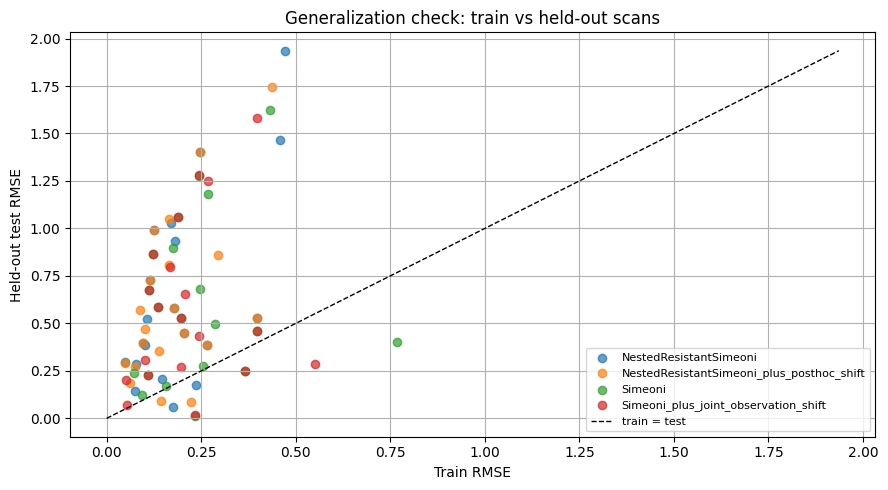

Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\plots\train_vs_test_rmse_scatter.png


In [17]:
# ---------------------------------------------------------------------
# Generalization gap: test RMSE - train RMSE
# ---------------------------------------------------------------------

holdout_metrics = holdout_metrics.copy()
holdout_metrics["generalization_gap"] = holdout_metrics["test_rmse"] - holdout_metrics["train_rmse"]
holdout_metrics["test_over_train_ratio"] = holdout_metrics["test_rmse"] / holdout_metrics["train_rmse"].clip(lower=1e-8)

gap_summary = (
    holdout_metrics
    .groupby("model")
    .agg(
        median_gap=("generalization_gap", "median"),
        mean_gap=("generalization_gap", "mean"),
        median_ratio=("test_over_train_ratio", "median"),
        mean_ratio=("test_over_train_ratio", "mean"),
    )
    .sort_values("median_gap")
)

display(gap_summary)

fig, ax = plt.subplots(figsize=(9, 5))

for model, g in holdout_metrics.groupby("model"):
    ax.scatter(g["train_rmse"], g["test_rmse"], alpha=0.7, label=model)

max_val = max(holdout_metrics["train_rmse"].max(), holdout_metrics["test_rmse"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1, color="black", label="train = test")

ax.set_xlabel("Train RMSE")
ax.set_ylabel("Held-out test RMSE")
ax.set_title("Generalization check: train vs held-out scans")
ax.legend(fontsize=8)

fig.tight_layout()
plot_path = PLOT_DIR / "train_vs_test_rmse_scatter.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

In [18]:
# ---------------------------------------------------------------------
# Wide per-patient comparison
# ---------------------------------------------------------------------

wide_test = (
    holdout_metrics
    .pivot_table(
        index=["study_id", "patient_id"],
        columns="model",
        values="test_rmse",
        aggfunc="first",
    )
    .reset_index()
)

wide_train = (
    holdout_metrics
    .pivot_table(
        index=["study_id", "patient_id"],
        columns="model",
        values="train_rmse",
        aggfunc="first",
    )
    .reset_index()
)

wide_test_path = OUT_DIR / "holdout_test_rmse_wide.csv"
wide_train_path = OUT_DIR / "holdout_train_rmse_wide.csv"

wide_test.to_csv(wide_test_path, index=False)
wide_train.to_csv(wide_train_path, index=False)

print("Test RMSE wide:")
display(wide_test)

print("Train RMSE wide:")
display(wide_train)

print("Saved:")
print(" ", wide_test_path)
print(" ", wide_train_path)

Test RMSE wide:


model,study_id,patient_id,NestedResistantSimeoni,NestedResistantSimeoni_plus_posthoc_shift,Simeoni,Simeoni_plus_joint_observation_shift
0,DATASET_263,201101018,0.141867,0.188308,0.240327,0.200955
1,DATASET_263,201103007,0.057332,0.091059,1.180911,1.249380
2,DATASET_263,201103018,0.287592,0.272752,0.227302,0.227302
3,DATASET_263,201103021,0.397322,0.397322,0.583759,0.586841
4,DATASET_263,201322001,0.581539,0.581539,1.062427,1.062427
5,DATASET_263,201715002,0.523578,0.572002,0.682186,0.272657
6,DATASET_263,201902001,0.388214,0.388214,0.250307,0.250303
7,DATASET_263,203303005,1.935857,1.746157,1.624451,1.581171
8,DATASET_263,203402003,0.992144,0.992144,0.864279,0.864279
9,DATASET_263,203404002,0.931271,0.809924,0.898453,0.797251


Train RMSE wide:


model,study_id,patient_id,NestedResistantSimeoni,NestedResistantSimeoni_plus_posthoc_shift,Simeoni,Simeoni_plus_joint_observation_shift
0,DATASET_263,201101018,0.076288,0.060966,0.073064,0.050917
1,DATASET_263,201103007,0.175034,0.143533,0.266850,0.269292
2,DATASET_263,201103018,0.078187,0.075864,0.108954,0.108954
3,DATASET_263,201103021,0.096888,0.096888,0.136822,0.136783
4,DATASET_263,201322001,0.177709,0.177709,0.189431,0.189431
5,DATASET_263,201715002,0.106583,0.087179,0.246251,0.196078
6,DATASET_263,201902001,0.266661,0.266661,0.364851,0.364851
7,DATASET_263,203303005,0.472400,0.437775,0.431022,0.398539
8,DATASET_263,203402003,0.125457,0.125457,0.123418,0.123418
9,DATASET_263,203404002,0.180446,0.163653,0.175818,0.168757


Saved:
  d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\holdout_test_rmse_wide.csv
  d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\holdout_train_rmse_wide.csv


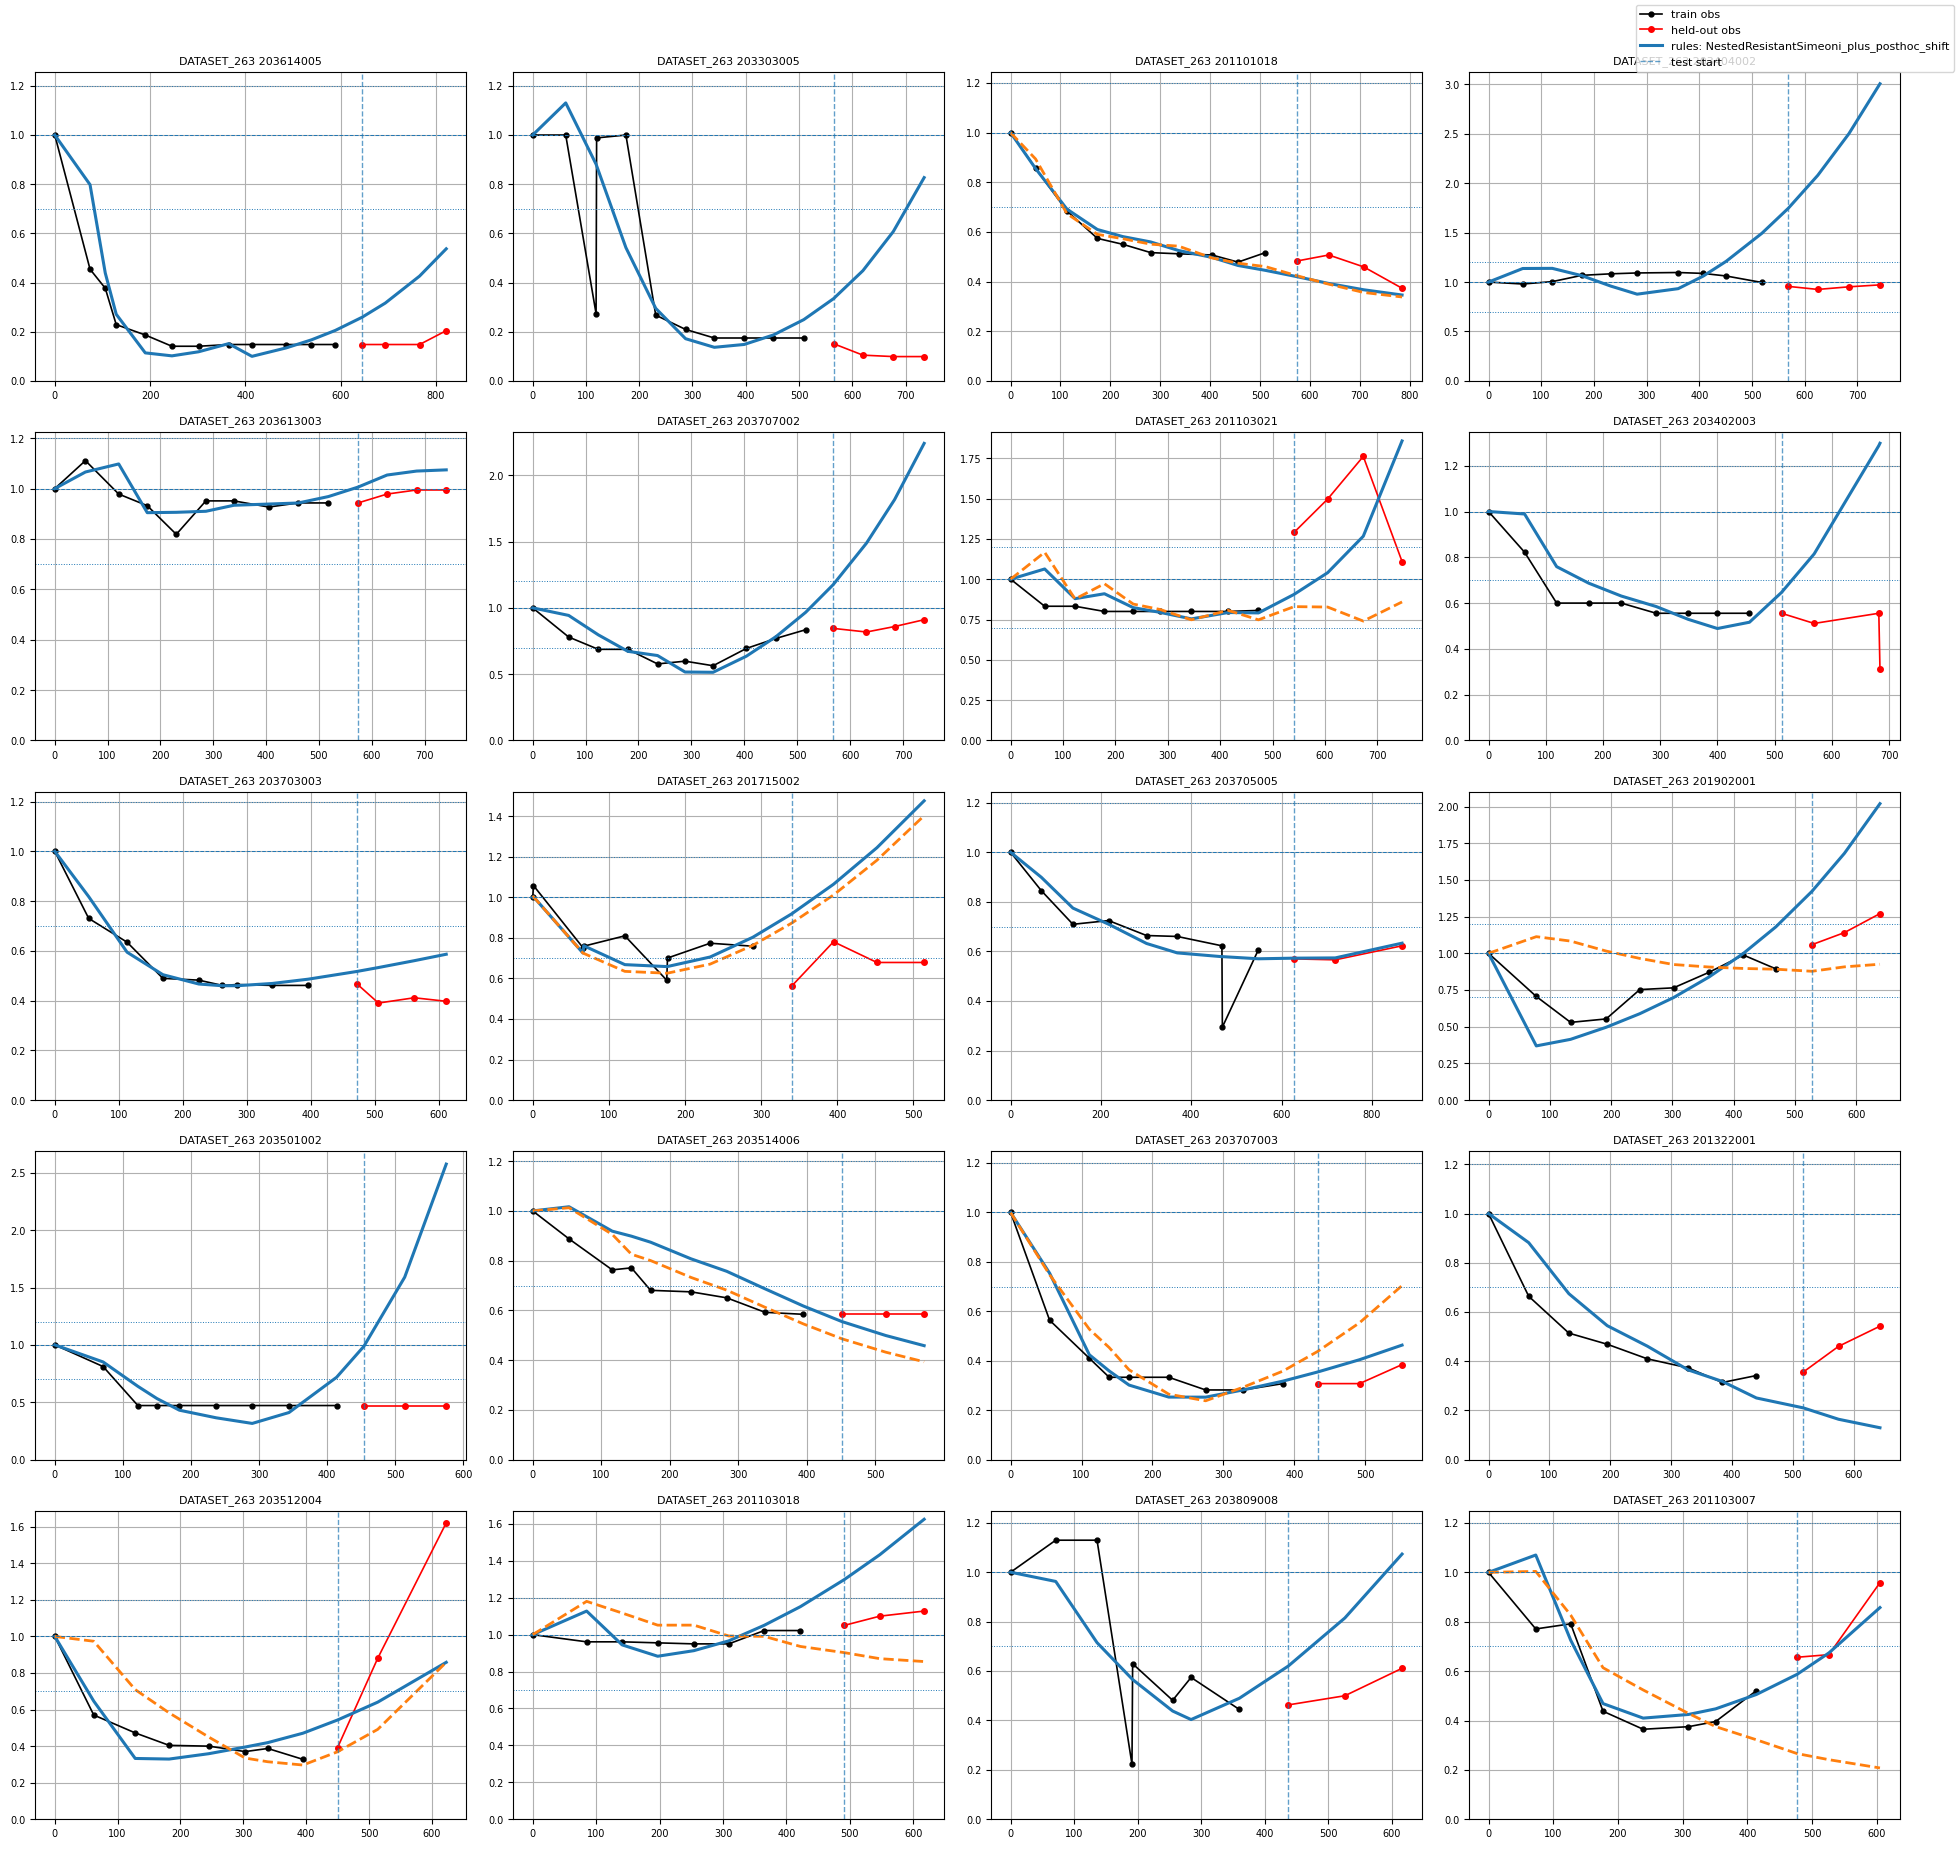

Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\plots\holdout_predictions_selected_models.png


In [19]:
# ---------------------------------------------------------------------
# Plot all hold-out predictions
# ---------------------------------------------------------------------

ok_keys = list(holdout_artifacts.keys())

n = len(ok_keys)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.9 * n_cols, 3.7 * n_rows),
    squeeze=False,
)
axes = axes.ravel()

for ax, key in zip(axes, ok_keys):
    item = holdout_artifacts[key]

    times = item["times"]
    obs_rel = item["obs_rel"]
    split = item["split"]
    sims = item["sims"]

    selected_rules = item["selected_by_rules"]
    selected_bic = item["selected_by_bic"]

    train_idx = split["train_idx"]
    test_idx = split["test_idx"]

    # Plot all observations with train/test distinction.
    ax.plot(
        times[train_idx],
        obs_rel[train_idx],
        "ko-",
        markersize=3.5,
        linewidth=1.2,
        label="train obs",
    )
    ax.plot(
        times[test_idx],
        obs_rel[test_idx],
        "ro-",
        markersize=4,
        linewidth=1.2,
        label="held-out obs",
    )

    # Plot selected models.
    ax.plot(
        times,
        sims[selected_rules],
        linewidth=2.2,
        label=f"rules: {selected_rules}",
    )

    if selected_bic != selected_rules:
        ax.plot(
            times,
            sims[selected_bic],
            linewidth=2.0,
            linestyle="--",
            label=f"BIC: {selected_bic}",
        )

    ax.axvline(
        times[test_idx[0]],
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="test start",
    )

    ax.axhline(1.0, linestyle="--", linewidth=0.7)
    ax.axhline(0.7, linestyle=":", linewidth=0.7)
    ax.axhline(1.2, linestyle=":", linewidth=0.7)

    ax.set_ylim(bottom=0)
    ax.set_title(key.replace("__", " "), fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(ok_keys):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=8)

fig.tight_layout(rect=(0, 0, 0.98, 0.98))
plot_path = PLOT_DIR / "holdout_predictions_selected_models.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

,study_id,patient_id,selected_by_rules,selected_by_bic,nested_f_r0,nested_k_sr,nested_lam0_r_mult,nested_k_kill_r_frac,nested_near_bound_count
0,DATASET_263,203614005,NestedResistantSimeoni_plus_posthoc_shift,NestedResistantSimeoni_plus_posthoc_shift,0.008614,0.000469,1.136794,0.000531,0
1,DATASET_263,203303005,Simeoni,Simeoni,0.004850,0.000099,0.989618,0.050026,0
2,DATASET_263,201101018,NestedResistantSimeoni_plus_posthoc_shift,Simeoni_plus_joint_observation_shift,0.000454,0.007715,0.443414,0.447329,1
3,DATASET_263,203404002,Simeoni,Simeoni,0.005000,0.000100,1.000000,0.050000,1
4,DATASET_263,203613003,Simeoni_plus_joint_observation_shift,Simeoni_plus_joint_observation_shift,0.028970,0.003868,0.607694,0.002642,1
5,DATASET_263,203707002,Simeoni,Simeoni,0.004935,0.000100,0.975352,0.050008,0
6,DATASET_263,201103021,NestedResistantSimeoni,Simeoni,0.000185,0.000024,1.568915,0.005992,1
7,DATASET_263,203402003,Simeoni,Simeoni,0.005043,0.000100,0.999574,0.050000,0
8,DATASET_263,203703003,NestedResistantSimeoni,NestedResistantSimeoni,0.016724,0.004264,0.319834,0.009841,1
9,DATASET_263,201715002,NestedResistantSimeoni_plus_posthoc_shift,NestedResistantSimeoni,0.320932,0.000493,0.991257,0.013310,1


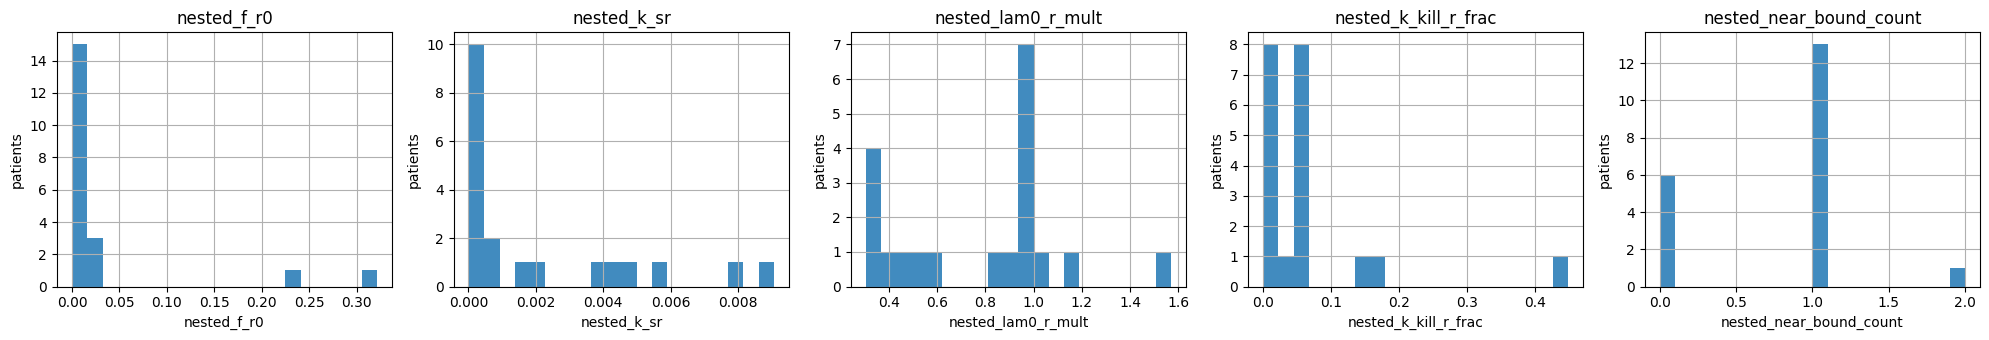

Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\plots\holdout_nested_parameter_sanity.png
Saved: d:\Projects\ml_redo\oncology-sbi-pkpd\outputs\notebook_01_holdout_validation\holdout_nested_parameter_sanity.csv


In [20]:
# ---------------------------------------------------------------------
# Parameter sanity for nested fits
# ---------------------------------------------------------------------

nested_param_rows = []

for key, item in holdout_artifacts.items():
    nested_row = item["nested_row"].copy()
    study_id, patient_id = key.split("__", 1)

    row = {
        "study_id": study_id,
        "patient_id": patient_id,
        "selected_by_rules": item["selected_by_rules"],
        "selected_by_bic": item["selected_by_bic"],
    }

    for col in nested_row.index:
        row[f"nested_{col}"] = nested_row[col]

    nested_param_rows.append(row)

nested_params = pd.DataFrame(nested_param_rows)

param_cols = [
    "nested_f_r0",
    "nested_k_sr",
    "nested_lam0_r_mult",
    "nested_k_kill_r_frac",
    "nested_near_bound_count",
]

available = [c for c in param_cols if c in nested_params.columns]

display(
    nested_params[
        ["study_id", "patient_id", "selected_by_rules", "selected_by_bic", *available]
    ]
)

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 3.5))

    if len(available) == 1:
        axes = [axes]

    for ax, col in zip(axes, available):
        ax.hist(pd.to_numeric(nested_params[col], errors="coerce").dropna(), bins=20, alpha=0.85)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("patients")

    fig.tight_layout()
    plot_path = PLOT_DIR / "holdout_nested_parameter_sanity.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", plot_path)

nested_params_path = OUT_DIR / "holdout_nested_parameter_sanity.csv"
nested_params.to_csv(nested_params_path, index=False)

print("Saved:", nested_params_path)

In [21]:
# ---------------------------------------------------------------------
# Auto-generate final validation conclusion
# ---------------------------------------------------------------------

summary_by_model_dict = (
    summary_by_model
    .reset_index()
    .to_dict(orient="records")
)

selection_summary_dict = selection_summary.to_dict(orient="records")

rules_selected = holdout_metrics[holdout_metrics["selected_by_train_rules"]].copy()
bic_selected = holdout_metrics[holdout_metrics["selected_by_train_bic"]].copy()

conclusion = {
    "n_patients_attempted": int(len(validation_patients)),
    "n_patients_successful": int(holdout_metrics[["study_id", "patient_id"]].drop_duplicates().shape[0]),
    "test_frac": float(TEST_FRAC),
    "median_test_rmse_by_model": {
        model: float(value)
        for model, value in holdout_metrics.groupby("model")["test_rmse"].median().items()
    },
    "mean_test_rmse_by_model": {
        model: float(value)
        for model, value in holdout_metrics.groupby("model")["test_rmse"].mean().items()
    },
    "rules_selection_counts": rules_selected["model"].value_counts().to_dict(),
    "bic_selection_counts": bic_selected["model"].value_counts().to_dict(),
    "median_test_rmse_rules_selected": float(rules_selected["test_rmse"].median()) if len(rules_selected) else None,
    "median_test_rmse_bic_selected": float(bic_selected["test_rmse"].median()) if len(bic_selected) else None,
    "summary_by_model": summary_by_model_dict,
    "selection_summary": selection_summary_dict,
}

conclusion_path = OUT_DIR / "holdout_validation_conclusion.json"

with open(conclusion_path, "w") as f:
    json.dump(conclusion, f, indent=2)

print(json.dumps(conclusion, indent=2))
print("Saved:", conclusion_path)

{
  "n_patients_attempted": 20,
  "n_patients_successful": 20,
  "test_frac": 0.25,
  "median_test_rmse_by_model": {
    "NestedResistantSimeoni": 0.4877477045080572,
    "NestedResistantSimeoni_plus_posthoc_shift": 0.4977428966086689,
    "Simeoni": 0.5134080737122215,
    "Simeoni_plus_joint_observation_shift": 0.4951012977131593
  },
  "mean_test_rmse_by_model": {
    "NestedResistantSimeoni": 0.6455518546360967,
    "NestedResistantSimeoni_plus_posthoc_shift": 0.6127963648239558,
    "Simeoni": 0.6021903570161795,
    "Simeoni_plus_joint_observation_shift": 0.5906097778102108
  },
  "rules_selection_counts": {
    "Simeoni": 9,
    "NestedResistantSimeoni": 6,
    "NestedResistantSimeoni_plus_posthoc_shift": 4,
    "Simeoni_plus_joint_observation_shift": 1
  },
  "bic_selection_counts": {
    "Simeoni": 14,
    "Simeoni_plus_joint_observation_shift": 3,
    "NestedResistantSimeoni": 2,
    "NestedResistantSimeoni_plus_posthoc_shift": 1
  },
  "median_test_rmse_rules_selected": 0.42

# Interpretation checklist

After running the notebook, inspect:

1. **Median held-out test RMSE by model**
   - If nested resistant-Simeoni wins on test RMSE, the biological extension is likely useful.
   - If it wins only on train RMSE but not test RMSE, it is probably overfitting.

2. **Train/test generalization gap**
   - Large gap for nested models means the model is too flexible or optimization is unstable.
   - Similar train and test RMSE means the model is predictive.

3. **BIC-selected model vs rule-selected model**
   - If both often select the same model, selection is robust.
   - If BIC prefers simpler models but RMSE rules prefer nested models, inspect plots carefully.

4. **Parameter sanity**
   - Many near-bound nested parameters suggest identifiability problems.
   - Stable distributions of resistant fraction, transition rate, and resistant kill fraction are encouraging.

5. **Plots**
   - Look for whether the selected model predicts the held-out future trend, not merely the training trajectory.

Decision rule:

```text
If nested models improve held-out prediction:
    proceed to synthetic SBI with nested resistant-Simeoni + robust observation model.

If nested models only improve train fit:
    tighten priors, reduce model flexibility, or improve observation model before SBI.

If simple Simeoni is competitive on held-out prediction:
    keep Simeoni as the main simulator and use nested resistance only as a secondary model class.